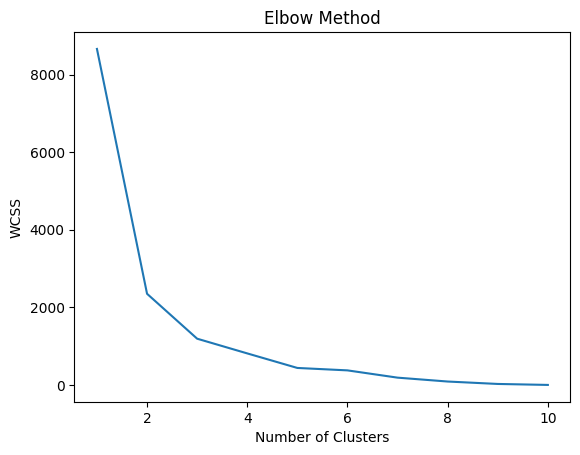

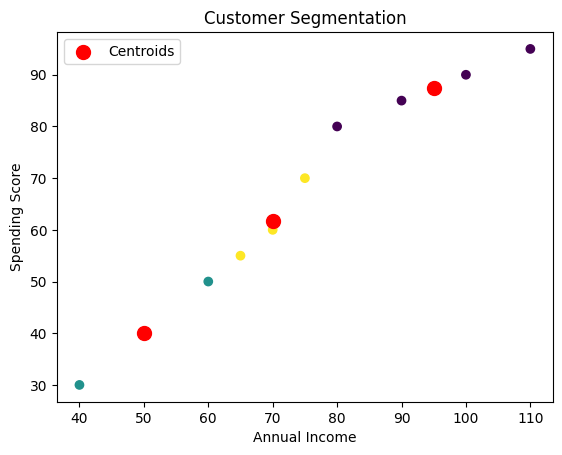

Cluster 0:
   CustomerID  AnnualIncome  SpendingScore  Cluster
1           2            80             80        0
3           4           100             90        0
5           6            90             85        0
7           8           110             95        0
Cluster 1:
   CustomerID  AnnualIncome  SpendingScore  Cluster
0           1            60             50        1
2           3            40             30        1
6           7            50             40        1
Cluster 2:
   CustomerID  AnnualIncome  SpendingScore  Cluster
4           5            70             60        2
8           9            65             55        2
9          10            75             70        2


In [1]:
# prompt: Customer Segmentation using K-Means Clustering (Python, Scikit-learn)

import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Sample customer data (replace with your actual data)
data = {
    'CustomerID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'AnnualIncome': [60, 80, 40, 100, 70, 90, 50, 110, 65, 75],
    'SpendingScore': [50, 80, 30, 90, 60, 85, 40, 95, 55, 70]
}
df = pd.DataFrame(data)

# Select features for clustering
X = df[['AnnualIncome', 'SpendingScore']]

# Determine optimal number of clusters (e.g., using the Elbow method)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Apply K-Means clustering with the chosen number of clusters (e.g., 3)
kmeans = KMeans(n_clusters=3, random_state=0)  # Adjust n_clusters based on the elbow method
df['Cluster'] = kmeans.fit_predict(X)

# Visualize the clusters
plt.scatter(df['AnnualIncome'], df['SpendingScore'], c=df['Cluster'])
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=100, c='red', label='Centroids')
plt.title('Customer Segmentation')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

# Analyze each cluster
for cluster in range(3):  # Adjust based on the number of clusters
    print(f'Cluster {cluster}:')
    print(df[df['Cluster'] == cluster])




